# 03 Perceptron, MLP & Framework Setup

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Check TensorFlow and PyTorch setup and compare deep learning vs traditional ML
- Implement a simple perceptron from scratch and train it on a tiny task (e.g. AND gate)
- Build a small MLP in TensorFlow and in PyTorch so you see both frameworks

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 3, lesson 02 "The Neuron, Perceptron, and XOR Problem" — the perceptron you coded there and the limit you found; here it becomes an MLP, in two frameworks.

---

## 🌍 Real life

**📌 Real case — the machine, and the proof that stopped it.** Rosenblatt's **Mark I Perceptron** (Cornell Aeronautical Laboratory, 1958–60) was physical hardware: a 20×20 grid of 400 photocells for an eye, 512 association units whose weights were motor-driven potentiometers, and 8 response units. It genuinely learned to classify patterns. Then Minsky and Papert's *Perceptrons* (1969) proved that one layer of weights cannot compute XOR — no matter how long you train it — and the field's funding and confidence collapsed for over a decade. The fix is the single line you add below: a hidden layer.

**⚡ Why this matters — what goes wrong without it.** That collapse was not caused by a bug or by slow hardware. It was a statement about *representation*: a single layer can only separate classes that a straight line (or flat plane) separates. Your from-scratch perceptron below learns AND perfectly — weights `[0.2, 0.1]`, bias `-0.2`, predictions `[0, 0, 0, 1]` — because AND is linearly separable. No weight and bias you can write down will ever give XOR. Every hidden layer you stack afterwards exists to buy representational power that "train it harder" cannot.

**Where is this used?** Perceptrons and MLPs are the **building blocks** of deep learning. TensorFlow and PyTorch are the two main frameworks used in **industry and research** for training neural networks.

**In this notebook we use** a **perceptron** (one neuron) and an **MLP** (multiple layers) to **see how frameworks define and run models**. We use **both TensorFlow and PyTorch** (instead of only one) **because** in real life you will meet both; knowing how to build a small MLP in each gets you ready for Units 2–5.

**📌 Covers slide(s):** **02** — ANNs, perceptron, MLP, activation, Keras; **06** — TensorFlow vs PyTorch, Colab, Jupyter. *Do this notebook after those slides.*

---

**Before starting:** Run the imports cell below. If TensorFlow or PyTorch fails, see `DOCS/COLAB_SETUP.md`.


## Theory (short)

- **Perceptron** = one neuron: inputs × weights + bias → step function; can learn simple linear boundaries (e.g. AND gate).
- **MLP (Multi-Layer Perceptron)** = several layers of neurons (Dense/Linear); can learn non-linear patterns; this is what we used in 02_simple_neural_network.
- **TensorFlow/Keras**: high-level API (`Sequential`, `Dense`); easy to get started; common in industry.
- **PyTorch**: `nn.Module`, `nn.Linear`; dynamic graph; common in research. Both are used in real projects.
- **Data flow:** input → layer 1 → activation → layer 2 → … → output. Frameworks automate backprop and optimizer.



## 📥 Inputs & 📤 Outputs

**Inputs:** NumPy, Matplotlib, TensorFlow (optional), PyTorch (optional). We use a tiny AND-gate dataset for the perceptron; no dataset for the MLP build (structure only).

**Dataset:** Synthetic — tiny AND-gate (built in notebook); no external data for the MLP structure demo.

**Outputs:** Printed framework versions (TF, PyTorch), a short DL vs ML comparison, the perceptron's weights after training on the AND gate **plus a six-panel storyboard of its decision boundary moving update by update with the matching step table**, and small MLP model summaries (TF and PyTorch).


In [1]:
# Step 1: Imports and framework check
import numpy as np
import matplotlib.pyplot as plt

# Try TensorFlow first; a broken install raises a clear fix message instead of a confusing traceback.
try:
    import tensorflow as tf
    HAS_TF = True
    print(f"✅ TensorFlow {tf.__version__}")
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False
    print("⚠️ TensorFlow not found. Install: pip install tensorflow")

# Try PyTorch independently - the notebook can still run with only one framework available.
try:
    import torch
    HAS_TORCH = True
    print(f"✅ PyTorch {torch.__version__}")
except ImportError:
    HAS_TORCH = False
    print("⚠️ PyTorch not found. Install: pip install torch")

print("✅ NumPy and Matplotlib ready.")

✅ TensorFlow 2.21.0


✅ PyTorch 2.13.0
✅ NumPy and Matplotlib ready.


## Step 2: Deep Learning vs Traditional ML (short)


In [2]:
# We use this comparison so students see why we use DL (automatic features) instead of manual feature engineering.
# Print a compact comparison students can refer back to when choosing an approach.
print("DL vs Traditional ML (short):")
print("  Features: DL learns from raw data; traditional ML often needs hand-designed features.")
print("  Data: DL benefits from more data; traditional ML can work with less.")
print("  Use: DL excels at images, text, audio; traditional ML is strong on tabular/structured data.")
print("✅ Deep learning automatically learns features — that's why we use it for complex patterns.")

DL vs Traditional ML (short):
  Features: DL learns from raw data; traditional ML often needs hand-designed features.
  Data: DL benefits from more data; traditional ML can work with less.
  Use: DL excels at images, text, audio; traditional ML is strong on tabular/structured data.
✅ Deep learning automatically learns features — that's why we use it for complex patterns.


## Step 3: Perceptron from scratch (we use it instead of an MLP here because we want to see one neuron learn a simple rule)


In [3]:
# Perceptron = one neuron: out = step(w·x + b). We use it to learn AND gate (instead of hand-coded AND) to see weights learned from data.
class Perceptron:
    def __init__(self, n_inputs, lr=0.1):
        # Start with zero weights; the learning rule below will adjust them from data.
        self.weights = np.zeros(n_inputs)
        self.bias = 0.0
        self.lr = lr
        # history keeps the weights after every single update so we can REPLAY the learning below.
        self.history = []

    # Step activation: fire (1) if the weighted sum crosses the threshold, otherwise stay silent (0).
    def step(self, x):
        return 1 if x >= 0 else 0

    def forward(self, x):
        return self.step(np.dot(x, self.weights) + self.bias)

    # Perceptron learning rule: nudge weights toward the correct answer whenever a prediction is wrong.
    def fit(self, X, y, epochs=10):
        # Record the state BEFORE any update, then after every sample, so the learning
        # can be redrawn as a sequence of pictures instead of one final number.
        self.history = [dict(step=0, epoch=0, x=None, target=None, pred=None, err=None,
                             w=self.weights.copy(), b=self.bias)]
        step = 0
        for ep in range(epochs):
            for xi, yi in zip(X, y):
                pred = self.forward(xi)
                err = yi - pred
                self.weights += self.lr * err * xi
                self.bias += self.lr * err
                step += 1
                self.history.append(dict(step=step, epoch=ep + 1, x=xi.copy(),
                                         target=int(yi), pred=int(pred), err=int(err),
                                         w=self.weights.copy(), b=self.bias))

# AND gate: (0,0)->0, (0,1)->0, (1,0)->0, (1,1)->1
X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]], dtype=np.float32)
y_and = np.array([0, 0, 0, 1])
# Train on the four AND examples and check the learned weights reproduce the truth table.
p = Perceptron(n_inputs=2)
p.fit(X_and, y_and)
print("Perceptron weights after AND gate:", p.weights)
print("Bias:", p.bias)
print("Predictions:", [p.forward(x) for x in X_and])
print("Expected:   ", y_and.tolist())

Perceptron weights after AND gate: [0.2 0.1]
Bias: -0.20000000000000004
Predictions: [0, 0, 0, 1]
Expected:    [0, 0, 0, 1]


## Step 3b: See the neuron learn, do not just read its final weights

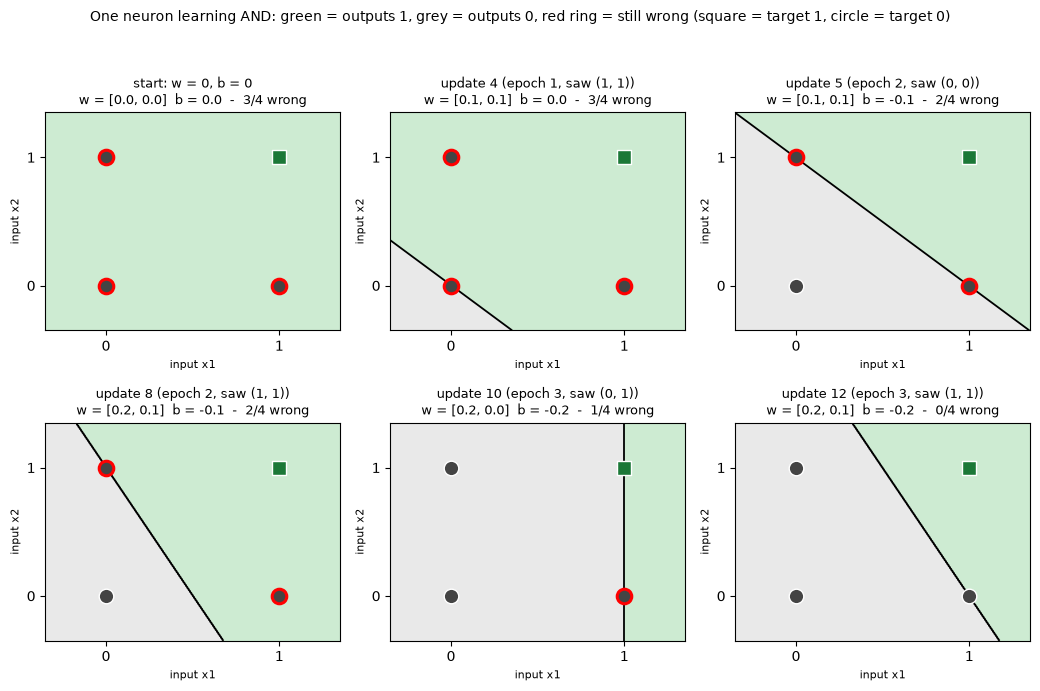

step  epoch  input   target  said  error   ->   w1     w2      b      wrong/4
   0      -       -       -     -      -   ->   0.00   0.00   0.00     3/4
   1      1  (0, 0)       0     1     -1   ->   0.00   0.00  -0.10     1/4
   2      1  (0, 1)       0     0      0   ->   0.00   0.00  -0.10     1/4
   3      1  (1, 0)       0     0      0   ->   0.00   0.00  -0.10     1/4
   4      1  (1, 1)       1     0      1   ->   0.10   0.10   0.00     3/4
   5      2  (0, 0)       0     1     -1   ->   0.10   0.10  -0.10     2/4
   6      2  (0, 1)       0     1     -1   ->   0.10   0.00  -0.20     1/4
   7      2  (1, 0)       0     0      0   ->   0.10   0.00  -0.20     1/4
   8      2  (1, 1)       1     0      1   ->   0.20   0.10  -0.10     2/4
   9      3  (0, 0)       0     0      0   ->   0.20   0.10  -0.10     2/4
  10      3  (0, 1)       0     1     -1   ->   0.20   0.00  -0.20     1/4
  11      3  (1, 0)       0     1     -1   ->   0.10   0.00  -0.30     1/4
  12      3  (1, 1)   

In [4]:
# Step 3b: WATCH the single neuron learn - a storyboard of the decision boundary
# WHAT: replay p.history and draw the line w1*x1 + w2*x2 + b = 0 at six moments of training.
#       Green area = the neuron outputs 1 ("fires"); grey area = it outputs 0.
# WHY: the printed weights are the END of the story. The boundary swinging into place IS the story.
#      (Static frames, not an animation, so the picture always renders - in Jupyter, in Colab, in a PDF.)

def wrong_count(w, b):
    """How many of the four AND examples this (w, b) still gets wrong."""
    return int(sum((1 if (np.dot(x, w) + b) >= 0 else 0) != t for x, t in zip(X_and, y_and)))

# Keep the updates that actually moved the weights (err != 0), plus the starting state.
picks = [0] + [h["step"] for h in p.history if h["err"] not in (0, None)]
if len(picks) > 6:                      # at most 6 panels - cheap and readable on a projector
    keep = np.linspace(0, len(picks) - 1, 6).round().astype(int)
    picks = [picks[i] for i in keep]
frames = [p.history[s] for s in picks]

gx, gy = np.meshgrid(np.linspace(-0.35, 1.35, 220), np.linspace(-0.35, 1.35, 220))
fig, axes = plt.subplots(2, 3, figsize=(10.5, 7.0))
for ax, h in zip(axes.ravel(), frames):
    w, b = h["w"], h["b"]
    fires = (w[0] * gx + w[1] * gy + b >= 0).astype(float)   # 1 where the neuron outputs 1
    ax.contourf(gx, gy, fires, levels=[-0.5, 0.5, 1.5], colors=["#e9e9e9", "#cdebd2"])
    ax.contour(gx, gy, fires, levels=[0.5], colors="k", linewidths=1.3)   # the boundary itself
    for xi, ti in zip(X_and, y_and):
        pred = 1 if (np.dot(xi, w) + b) >= 0 else 0
        ax.scatter(*xi, marker="s" if ti == 1 else "o", s=110,
                   c="#1b7837" if ti == 1 else "#444444", zorder=3,
                   edgecolors="red" if pred != ti else "white",
                   linewidths=2.2 if pred != ti else 1.0)
    ttl = "start: w = 0, b = 0" if h["step"] == 0 else \
          f"update {h['step']} (epoch {h['epoch']}, saw {tuple(int(v) for v in h['x'])})"
    ax.set_title(f"{ttl}\nw = [{w[0]:.1f}, {w[1]:.1f}]  b = {b:.1f}  -  {wrong_count(w, b)}/4 wrong",
                 fontsize=9)
    ax.set_xlim(-0.35, 1.35); ax.set_ylim(-0.35, 1.35)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xlabel("input x1", fontsize=8); ax.set_ylabel("input x2", fontsize=8)
fig.suptitle("One neuron learning AND: green = outputs 1, grey = outputs 0, "
             "red ring = still wrong (square = target 1, circle = target 0)", fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

# The same story as a table, so every frame can be checked against numbers.
print("step  epoch  input   target  said  error   ->   w1     w2      b      wrong/4")
for h in p.history[:13]:
    if h["step"] == 0:
        print(f"{0:4d}  {'-':>5}  {'-':>6}  {'-':>6}  {'-':>4}  {'-':>5}   ->  "
              f"{h['w'][0]:5.2f}  {h['w'][1]:5.2f}  {h['b']:5.2f}     {wrong_count(h['w'], h['b'])}/4")
    else:
        print(f"{h['step']:4d}  {h['epoch']:5d}  {str(tuple(int(v) for v in h['x'])):>6}  "
              f"{h['target']:6d}  {h['pred']:4d}  {h['err']:5d}   ->  "
              f"{h['w'][0]:5.2f}  {h['w'][1]:5.2f}  {h['b']:5.2f}     {wrong_count(h['w'], h['b'])}/4")
print(f"\nNo weight changes after update 12: the remaining {len(p.history) - 13} updates all had error 0.")

# How much room does the final boundary leave? (w.x + b for each of the four inputs)
print("\nFinal distance from the boundary (w.x + b), one per input:")
for xi, ti in zip(X_and, y_and):
    print(f"  {tuple(int(v) for v in xi)} target {ti}:  {np.dot(xi, p.weights) + p.bias: .17f}")


**Read the storyboard.** Six of the 40 updates — the start, plus the updates that actually moved the weights.

- **Panel 1 (start).** `w = [0, 0]`, `b = 0`, so `w·x + b = 0` for every input, and the step rule fires whenever the sum is `>= 0`. The neuron therefore answers **1 to everything**: the whole plane is green and 3 of the 4 examples carry a red ring. A neuron that has learned nothing is not silent — it is confidently wrong.
- **Panels 2–5.** Each panel is an update where the answer was wrong, and the boundary jumps in response. Across the six panels the error count reads 3/4 → 3/4 → 2/4 → 2/4 → 1/4 → 0/4, but the **table underneath is the honest version**: after update 1 only 1 of 4 was wrong, and update 4 pushed it back up to 3. The perceptron rule repairs the single example in front of it, not the whole truth table, so progress is not monotone.
- **Panel 6 (update 12).** The line finally separates the one square (target 1) from the three circles: **0/4 wrong**. Every one of the remaining 28 updates leaves the weights untouched — that is exactly what "converged" means for this rule, and it is why the printed weights are `[0.2, 0.1]` with bias `-0.2`.

**The detail worth stopping on.** In panel 6 the boundary passes *through* the point (1, 0) — look at the circle sitting on the black line. The printed distance for that input is `-0.00000000000000003`: it is classified as 0 only because floating-point rounding left it a hair on the correct side. The perceptron rule stops at the **first** line that works and asks for no margin at all. Fixing that is the entire motivation for the SVM's maximum margin, and, less directly, for the sigmoid and softmax outputs used everywhere later in this course — they keep pushing for confidence after correctness has been reached.

**What it proves:** learning here is nothing but a boundary being nudged by wrong answers. **What it does not prove:** that this always works — a single neuron can only ever draw one straight line, which is why XOR defeats it and why Step 4 moves to a multi-layer network.

## Step 4: MLP with TensorFlow (we use Keras Sequential instead of raw TF so we build quickly)


In [5]:
# WHAT: define and compile a small MLP (4 inputs -> 8 hidden -> 2 outputs) in TensorFlow/Keras.
# WHY: seeing the same network in both frameworks shows the concepts transfer; only the syntax changes.
if HAS_TF:
    # Small MLP: 4 inputs -> 8 hidden -> 2 outputs (e.g. binary). We use Dense layers (not conv) because input is flat.
    model_tf = tf.keras.Sequential([
        tf.keras.layers.Dense(8, activation="relu", input_shape=(4,)),
        tf.keras.layers.Dense(2, activation="softmax"),
    ])
    model_tf.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    print("TensorFlow MLP summary:")
    model_tf.summary()
else:
    print("Skipping TF MLP (TensorFlow not available).")

TensorFlow MLP summary:


/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            18 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58 (232.00 B)

 Trainable params: 58 (232.00 B)

 Non-trainable params: 0 (0.00 B)

## Step 5: MLP with PyTorch (same idea as TF: Linear layers; we use nn.Sequential for quick build)


In [6]:
# WHAT: the identical 4 -> 8 -> 2 MLP, this time in PyTorch.
# WHY: comparing with the Keras version above shows both frameworks express the same math.
if HAS_TORCH:
    # Same structure as TF: 4 -> 8 -> 2. We use nn.Linear (PyTorch) instead of Dense (Keras); same idea.
    model_pt = torch.nn.Sequential(
        torch.nn.Linear(4, 8),
        torch.nn.ReLU(),
        torch.nn.Linear(8, 2),
    )
    print("PyTorch MLP:")
    print(model_pt)
else:
    print("Skipping PyTorch MLP (PyTorch not available).")

PyTorch MLP:
Sequential(
  (0): Linear(in_features=4, out_features=8, bias=True)
  (1): ReLU()
  (2): Linear(in_features=8, out_features=2, bias=True)
)


## 💬 Discuss

1. Your perceptron solved AND with weights `[0.2, 0.1]` and bias `-0.2`. Spend three minutes trying to find weights and a bias that give XOR — or write down the argument for why you cannot. What does your answer say about the advice "just train it longer"?
2. The same 4→8→2 network is above in Keras and in PyTorch, and the mathematics is identical. On what grounds should a team in Riyadh standardise on one of them? List three criteria that have nothing to do with the math — then decide which one outranks the others and defend it.
3. Keras printed a parameter table with shapes and counts; PyTorch printed a module list. If a regulator asked you to document the model you deployed, which output would you rather hand over, and what would you have to add to the other one to match it?


## 🌍 Real-World Worked Example — Handwritten Digit Recognition

**Industry context:** The US Postal Service has been using digit recognition since the 1980s.  
ATMs, banks, and postal systems worldwide classify millions of handwritten digits daily.

Below we train a neural network on **real** digit images (same family as MNIST, 8×8 pixels, sklearn built-in — no download needed).

Test accuracy on real handwritten digits: 96.9%


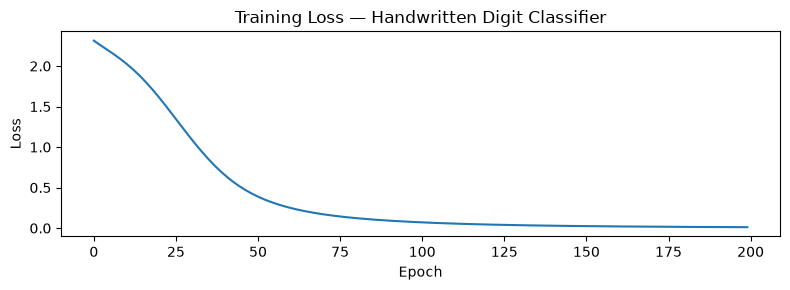

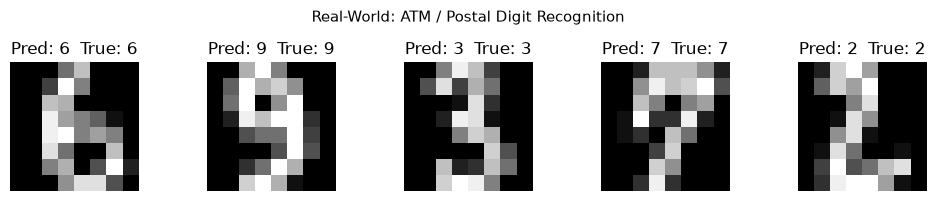

In [7]:
import torch, torch.nn as nn, torch.optim as optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np, matplotlib.pyplot as plt

# ── Real digit images (1797 samples, 8×8 pixels) ──────────────────────────
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target

# Split FIRST (the 8×8 images travel with their rows), then scale with
# statistics from the training set only (no test-set leakage).
X_tr, X_te, y_tr, y_te, img_tr, img_te = train_test_split(
    X, y, digits.images, test_size=0.2, random_state=42)
scaler = StandardScaler().fit(X_tr)
X_tr = scaler.transform(X_tr).astype(np.float32)
X_te = scaler.transform(X_te).astype(np.float32)

X_tr_t = torch.tensor(X_tr)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
X_te_t = torch.tensor(X_te)
y_te_t = torch.tensor(y_te, dtype=torch.long)

# ── Two-layer neural network ───────────────────────────────────────
# Fix the seed so this demo prints the same accuracy every run (and the same number
# in notebooks 01, 02 and 03, which all run this identical example).
torch.manual_seed(0)
model = nn.Sequential(
    nn.Linear(64, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 10)
)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.CrossEntropyLoss()
losses    = []

for epoch in range(200):
    model.train()
    pred = model(X_tr_t)
    loss = loss_fn(pred, y_tr_t)
    optimizer.zero_grad(); loss.backward(); optimizer.step()
    losses.append(loss.item())

# ── Evaluation ──────────────────────────────────────────────────────
model.eval()
with torch.no_grad():
    acc = (model(X_te_t).argmax(1) == y_te_t).float().mean().item()

print(f"Test accuracy on real handwritten digits: {acc*100:.1f}%")

# ── Plot training loss ──────────────────────────────────────────────
plt.figure(figsize=(8, 3))
plt.plot(losses)
plt.title("Training Loss — Handwritten Digit Classifier"); plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.tight_layout(); plt.show()

# ── Show sample predictions: test images paired with their own labels ─────
with torch.no_grad():
    sample_preds = model(X_te_t[:5]).argmax(1).tolist()

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i, ax in enumerate(axes):
    ax.imshow(img_te[i], cmap='gray')   # the SAME test image the model predicted on
    ax.set_title(f"Pred: {sample_preds[i]}  True: {y_te[i]}")
    ax.axis('off')
plt.suptitle("Real-World: ATM / Postal Digit Recognition", fontsize=11)
plt.tight_layout(); plt.show()

**Read the two figures.**

- **Loss curve** — a 3-layer network on 1,437 real 8×8 digit images, full batch, 200 epochs. It starts at about **2.3**, which is ln 10: the loss of a model answering "all ten digits equally likely". By epoch 200 it is essentially 0. That is *training* loss, on images the model is free to memorise, so on its own it proves nothing.
- **Five test digits** — images from the 360 held-out samples the model never trained on, each with its prediction and true label. All five are right, and the honest number is next to them: **96.9%** on the whole held-out set.

**Careful with both.** A training-loss curve that reaches zero and five hand-picked correct predictions are the two most common ways a result gets oversold. The claim that survives review is the held-out accuracy — and better still, a confusion matrix over every test image (notebook 02, Step 9).

## ⚠️ Where this breaks

- **The perceptron only works on linearly separable problems.** AND, yes. XOR, never — and almost nothing real is AND-shaped. If your training loop refuses to converge on a single-layer model, more epochs will not help; you need a hidden layer.
- **"Same math, different syntax" is only mostly true.** The 4→8→2 model is identical in both frameworks above, but the defaults are not: initialisation schemes differ, and the loss/output boundary differs — Keras commonly ends with `Dense(10, activation='softmax')` plus `sparse_categorical_crossentropy`, while PyTorch (see notebook `02`) emits **raw logits** and lets `CrossEntropyLoss` apply softmax internally. Add a softmax to a PyTorch model that already feeds `CrossEntropyLoss` and you will apply it twice, train a worse model, and get no error message. Copying hyperparameters from a paper written in the other framework is a standard way to lose a week.
- **This notebook trains nothing real.** The MLPs are built and summarised, not fitted to data. Parameter counts and shapes are trustworthy; nothing here is evidence about accuracy.
- **The assumption that must hold for framework choice to be free:** your project stays small. As soon as you need distributed training, quantization (`unit5/07`), or a specific serving stack (`unit5/02`), the framework stops being a matter of taste and starts constraining what you can ship.


## 🧩 Mini-exercise

**Try it:** In a new code cell, print the version of TensorFlow and of PyTorch (e.g. `tf.__version__` and `torch.__version__`). If one of them failed to import, note which one and what you would do to fix it.

---

## ✅ Summary

**What you did:**
- Checked TensorFlow and PyTorch setup.
- Compared deep learning vs traditional ML in one line each.
- Implemented a perceptron from scratch and trained it on the AND gate (weights learned from data).
- Built a small MLP in TensorFlow (Keras Sequential) and in PyTorch (nn.Sequential).

**In real life you'd also:** Train the MLP on real data (e.g. MNIST), tune learning rate and layer sizes, and choose one framework per project.

**The main idea:** A perceptron is one neuron; an MLP is many layers. TensorFlow and PyTorch both define layers and run backprop; knowing how to build a small MLP in each prepares you for the rest of the course.

**Next:** `07_image_processing_feature_extraction` covers image basics and feature extraction before we use CNNs.


## 📚 References

1. Rosenblatt, F. (1958). *The Perceptron: A Probabilistic Model for Information Storage and Organization in the Brain*. Psychological Review 65(6), 386-408.
2. Rumelhart, D. E., Hinton, G. E. & Williams, R. J. (1986). *Learning representations by back-propagating errors*. Nature 323, 533-536. https://doi.org/10.1038/323533a0
3. Abadi, M. et al. (2016). *TensorFlow: Large-Scale Machine Learning on Heterogeneous Distributed Systems*. arXiv. https://arxiv.org/abs/1603.04467
4. Paszke, A. et al. (2019). *PyTorch: An Imperative Style, High-Performance Deep Learning Library*. NeurIPS. https://arxiv.org/abs/1912.01703

**Recent work (2024–2026)**

5. Ansel, J. et al. (2024). *PyTorch 2: Faster Machine Learning Through Dynamic Python Bytecode Transformation and Graph Compilation*. ASPLOS '24. https://doi.org/10.1145/3620665.3640366 — the paper behind `torch.compile` — the single biggest change to how PyTorch runs since the version you are installing here.
6. OpenAI (2025). *gpt-oss-120b & gpt-oss-20b Model Card*. arXiv. https://arxiv.org/abs/2508.10925 — where this setup leads: in 2026 the same two frameworks load open-weight, frontier-class models that ship with a published model card you can read.
